# Compare models

### Setup & Imports

In [ ]:
import os
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch.utils.data import DataLoader

from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

from config import ExperimentConfig
from dataset import WhaleDataset, build_dataloaders, build_train_transform, build_val_transform, prepare_data
from models import build_model
from evaluation import extract_embeddings, evaluate_retrieval

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
BIN_ORDER = ["1 image", "2-5 images", "6-10 images", "11+ images"]


def cleanup_memory(*names, scope=None):
    if scope is None:
        scope = globals()
    for n in names:
        if n in scope:
            del scope[n]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def tensor_to_image(tensor):
    """Undo normalization for visualization."""
    arr = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    arr = np.clip(arr * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)
    return arr


def n_shot_bin(n):
    if n == 1:
        return "1 image"
    if 2 <= n <= 5:
        return "2-5 images"
    if 6 <= n <= 10:
        return "6-10 images"
    return "11+ images"


def compute_top1_predictions(model, gallery_loader, query_loader, idx_to_class_count, device, chunk_size=256):
    if model is None:
        return None

    gallery_emb, gallery_labels = extract_embeddings(model, gallery_loader, device)
    query_emb, query_labels = extract_embeddings(model, query_loader, device)

    known_gallery = gallery_labels >= 0
    gallery_emb = gallery_emb[known_gallery]
    gallery_labels = gallery_labels[known_gallery]

    if gallery_emb.size(0) == 0:
        return pd.DataFrame()

    records = []
    for start in range(0, len(query_emb), chunk_size):
        end = min(start + chunk_size, len(query_emb))
        q = query_emb[start:end]
        q_labels = query_labels[start:end]

        sims = q @ gallery_emb.t()
        top_sim, top_idx = sims.max(dim=1)
        pred_labels = gallery_labels[top_idx]

        for i in range(len(q)):
            true_label = int(q_labels[i].item())
            pred_label = int(pred_labels[i].item())
            max_similarity = float(top_sim[i].item())
            is_known = true_label >= 0
            class_size = idx_to_class_count.get(true_label, 0) if is_known else 0

            records.append({
                "true_label": true_label,
                "pred_label": pred_label,
                "max_similarity": max_similarity,
                "is_known": is_known,
                "is_new_whale": true_label == -1,
                "class_size": class_size,
                "n_shot_bin": n_shot_bin(class_size) if is_known else "new_whale",
                "is_correct": bool(is_known and (pred_label == true_label)),
            })

    return pd.DataFrame(records)


def summarize_model_predictions(pred_df, threshold=0.5):
    if pred_df is None or len(pred_df) == 0:
        return {}

    known_df = pred_df[pred_df["is_known"]]

    metrics = {
        "n_queries": int(len(pred_df)),
        "n_known_queries": int(pred_df["is_known"].sum()),
        "n_new_queries": int((~pred_df["is_known"]).sum()),
    }

    if len(known_df) > 0:
        y_true_known = known_df["true_label"].values
        y_pred_known = known_df["pred_label"].values
        metrics["known_accuracy"] = float(accuracy_score(y_true_known, y_pred_known))
        metrics["known_f1_weighted"] = float(f1_score(y_true_known, y_pred_known, average="weighted", zero_division=0))
        metrics["known_f1_macro"] = float(f1_score(y_true_known, y_pred_known, average="macro", zero_division=0))
    else:
        metrics["known_accuracy"] = np.nan
        metrics["known_f1_weighted"] = np.nan
        metrics["known_f1_macro"] = np.nan

    y_true_new = (~pred_df["is_known"]).astype(int).values  # 1 if new whale
    y_score_new = -pred_df["max_similarity"].values          # higher means more likely new
    y_pred_new = (pred_df["max_similarity"] < threshold).astype(int).values

    metrics["open_set_accuracy"] = float(accuracy_score(y_true_new, y_pred_new))
    metrics["new_whale_recall"] = float(((y_pred_new == 1) & (y_true_new == 1)).sum() / max((y_true_new == 1).sum(), 1))
    metrics["new_whale_f1"] = float(f1_score(y_true_new, y_pred_new, zero_division=0))

    if len(np.unique(y_true_new)) >= 2:
        metrics["open_set_auc"] = float(roc_auc_score(y_true_new, y_score_new))
    else:
        metrics["open_set_auc"] = np.nan

    return metrics


def plot_embedding_tsne(model, loader, data, device, title="", max_samples=700, top_k_classes=10, min_samples_per_class=5):
    """t-SNE style aligned with notebook 02: top frequent classes + centroid labels."""
    if model is None:
        print(f"[skip] {title}: model is missing.")
        return

    emb_t, lab_t = extract_embeddings(model, loader, device)
    emb = emb_t.cpu().numpy()
    lab = lab_t.cpu().numpy()

    known_mask = lab >= 0
    emb = emb[known_mask]
    lab = lab[known_mask]

    if len(emb) < 30:
        print(f"[skip] {title}: too few known samples.")
        return

    unique, counts = np.unique(lab, return_counts=True)
    frequent = unique[counts >= min_samples_per_class]
    if len(frequent) == 0:
        frequent = unique[counts >= 2]
    if len(frequent) == 0:
        print(f"[skip] {title}: no classes with enough samples.")
        return

    freq_counts = {c: int(counts[unique == c][0]) for c in frequent}
    top_classes = sorted(freq_counts, key=freq_counts.get, reverse=True)[:top_k_classes]

    class_mask = np.isin(lab, top_classes)
    emb = emb[class_mask]
    lab = lab[class_mask]

    if len(emb) > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(emb), size=max_samples, replace=False)
        emb = emb[idx]
        lab = lab[idx]

    if len(np.unique(lab)) < 2:
        print(f"[skip] {title}: t-SNE needs at least 2 classes.")
        return

    perplexity = min(max(len(emb) // 8, 5), 50)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1500,
        init="pca",
        learning_rate="auto",
    )
    emb_2d = tsne.fit_transform(emb)

    plt.figure(figsize=(9.5, 9.0))
    cmap = plt.cm.get_cmap("tab10" if len(np.unique(lab)) <= 10 else "tab20")
    classes_sorted = sorted(np.unique(lab))

    for i, c in enumerate(classes_sorted):
        mask = lab == c
        color = cmap(i % cmap.N)
        whale_name = data["idx_to_id"].get(int(c), str(c))

        plt.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            s=48,
            alpha=0.82,
            color=color,
            edgecolors="white",
            linewidths=0.3,
            label=f"{whale_name[:10]} ({mask.sum()})",
        )

        cx, cy = emb_2d[mask, 0].mean(), emb_2d[mask, 1].mean()
        plt.annotate(
            whale_name[:10],
            (cx, cy),
            fontsize=8,
            xytext=(4, 3),
            textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    plt.title(title or "t-SNE of validation embeddings", fontsize=14)
    plt.xlabel("t-SNE component 1")
    plt.ylabel("t-SNE component 2")
    plt.grid(alpha=0.22)
    plt.legend(fontsize=8, frameon=True, loc="best", ncol=2)
    plt.tight_layout()
    plt.show()

Device: cpu


### Interpretation Guide: Dataset Distribution Plots

What this figure set shows:
1. **Left panel:** how many known identities fall into each N-shot bin.
2. **Right panel:** frequency-rank profile on log-log axes (long-tail diagnostics).

### Long-tail in plain language
- Imagine listing identities from most common to rarest.
- Rank `1` is the most photographed whale, rank `2` is the next, and so on.
- If the dataset is long-tail, a few identities have many images, while most identities have very few.


### Why log-log axes are used
- On a normal axis, very large values dominate and small values get visually squashed.
- A log axis turns multiplicative steps into equal visual steps:
  - Moving from `1` to `10` to `100` is evenly spaced.
- So log-log makes it easier to see both head classes and tail classes in one view.


### How to read slope on log-log
- A roughly straight descending segment means heavy-tail behavior.
- Steeper slope means frequency drops faster as rank increases (more imbalance).
- Flatter slope means slower decay (less extreme imbalance).
- Intuition: if rank doubles and frequency roughly halves repeatedly, you get a stable downward trend.


### How to connect this to model behavior
- Many classes in `1` and `2-5` bins means most classes are low-data.
- Low-data classes are where standard classification often struggles.
- Margin-based or metric-learning-style objectives may help, but only if the supervision signal fits the data regime.


Notes for next AI reviewer:
- If later metric-learning gains are concentrated in low-shot bins, this plot gives the data-regime reason.
- If gains happen only in high-shot bins, investigate objective mismatch with long-tail constraints.
- If open-set thresholding is unstable, verify whether the tail amplifies score variance in rare classes.

#### Code Block: Build Dataset Statistics and Plot Long-tail Curves

In [ ]:
from dataset import build_retrieval_eval_loaders


retrieval_eval_config = ExperimentConfig(
    data_dir="data",
    seed=42,
    stratified_split=True,
    include_new_whale_in_val=True,
    batch_size=12,
    num_workers=2,
    confidence_threshold=0.5,
)

data = prepare_data(retrieval_eval_config)
gallery_loader, query_loader = build_retrieval_eval_loaders(retrieval_eval_config, data)

train_class_counts = data["train_df"]["Id"].value_counts().to_dict()
idx_to_class_count = {
    idx: int(train_class_counts.get(whale_id, 0))
    for idx, whale_id in data["idx_to_id"].items()
}

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class


,Setting,Value
0,Retrieval k,5
1,Open-set threshold,0.5
2,Gallery split,train_df
3,Query split,val_df
4,Known identities in train split,4247
5,1-shot identity ratio (train split),53.59%


,N-shot bin,Train identities
0,1 image,2276
1,2-5 images,1829
2,6-10 images,101
3,11+ images,41


Evaluation protocol ready. Next: load checkpoints and evaluate Baseline -> ArcFace -> Triplet.


## Evaluate models

### Load models

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\krios\.cache\huggingface\hub\models--timm--efficientnet_b5.sw_in12k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[ok] Baseline loaded from experiments\20260402_175215_baseline_effnetb5_focal_bd5dccca\checkpoints\best.pth
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[ok] ArcFace loaded from experiments\20260403_163615_arcface_effnetb5_6c8d152f\checkpoints\best.pth
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[ok] Triplet loaded from experiments\20260404_143337_triplet_effnetb5_3ae3db53\checkpoints\best.pth
Available models: ['Baseline', 'ArcFace', 'Triplet']


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/338 [00:16<?, ?it/s]

  Extracting embeddings:   0%|          | 0/24 [00:15<?, ?it/s]

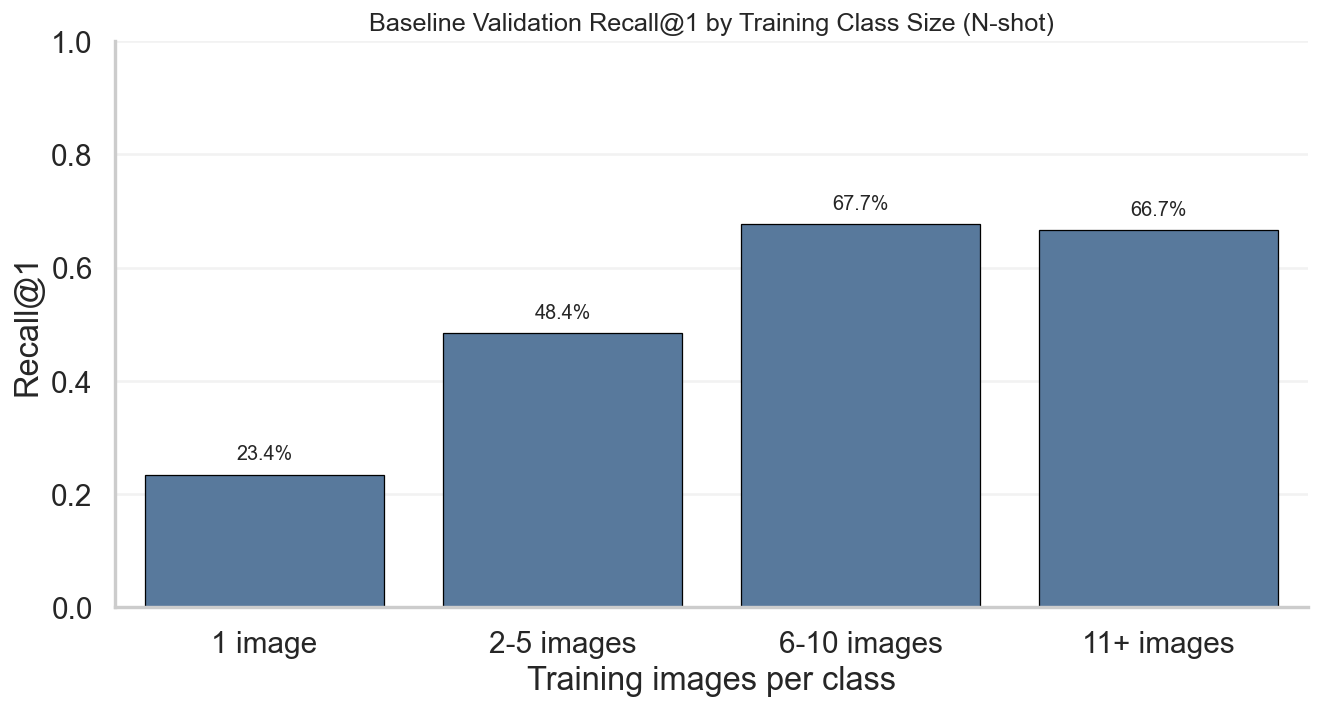

,n_shot_bin,recall_at_1
0,1 image,0.234375
1,2-5 images,0.484321
2,6-10 images,0.677419
3,11+ images,0.666667


,Metric,Baseline
0,n_queries,557.000000
1,n_known_queries,467.000000
2,n_new_queries,90.000000
3,known_accuracy,0.496788
4,known_f1_weighted,0.500255
5,known_f1_macro,0.343138
6,open_set_accuracy,0.838420
7,new_whale_recall,0.000000
8,new_whale_f1,0.000000
9,open_set_auc,0.494730


<Figure size 832x624 with 0 Axes>

In [ ]:
def latest_experiment_by_keyword(keyword):
    exp_root = Path("experiments")
    if not exp_root.exists():
        return None
    candidates = [d for d in exp_root.iterdir() if d.is_dir() and keyword in d.name.lower()]
    candidates = [d for d in candidates if (d / "checkpoints" / "best.pth").exists()]
    if not candidates:
        return None
    return sorted(candidates, key=lambda p: p.name)[-1]


def load_trained_model(exp_dir, model_name):
    if exp_dir is None:
        print(f"[warning] No experiment directory found for {model_name}.")
        return None, None, None

    config_path = exp_dir / "config.json"
    ckpt_path = exp_dir / "checkpoints" / "best.pth"

    if not config_path.exists() or not ckpt_path.exists():
        print(f"[warning] Missing config/checkpoint for {model_name} at {exp_dir}.")
        return None, None, None

    try:
        cfg = ExperimentConfig.load(str(config_path))
        model = build_model(cfg, data["num_classes"], device)
        state = torch.load(ckpt_path, map_location=device, weights_only=False)
        model_state = state.get("model_state_dict", state)
        model.load_state_dict(model_state)
        model.eval()
        print(f"[ok] {model_name} loaded from {ckpt_path}")
        return model, cfg, ckpt_path
    except Exception as e:
        print(f"[warning] Could not load {model_name}: {e}")
        return None, None, None


baseline_dir = latest_experiment_by_keyword("baseline")
arcface_dir = latest_experiment_by_keyword("arcface")
triplet_dir = latest_experiment_by_keyword("triplet")

baseline_model, baseline_cfg, baseline_ckpt = load_trained_model(baseline_dir, "Baseline")
arcface_model, arcface_cfg, arcface_ckpt = load_trained_model(arcface_dir, "ArcFace")
triplet_model, triplet_cfg, triplet_ckpt = load_trained_model(triplet_dir, "Triplet")

models_dict = {
    "Baseline": baseline_model,
    "ArcFace": arcface_model,
    "Triplet": triplet_model,
}
available_models = {k: v for k, v in models_dict.items() if v is not None}
print("Available models:", list(available_models.keys()))

## Embedding-Space Diagnostics

### Extract Embeddings and Plot Similarity Distributions

c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/24 [00:13<?, ?it/s]

Baseline: extracted 557 validation embeddings.


  Extracting embeddings:   0%|          | 0/24 [00:13<?, ?it/s]

ArcFace: extracted 557 validation embeddings.


  Extracting embeddings:   0%|          | 0/24 [00:13<?, ?it/s]

Triplet: extracted 557 validation embeddings.


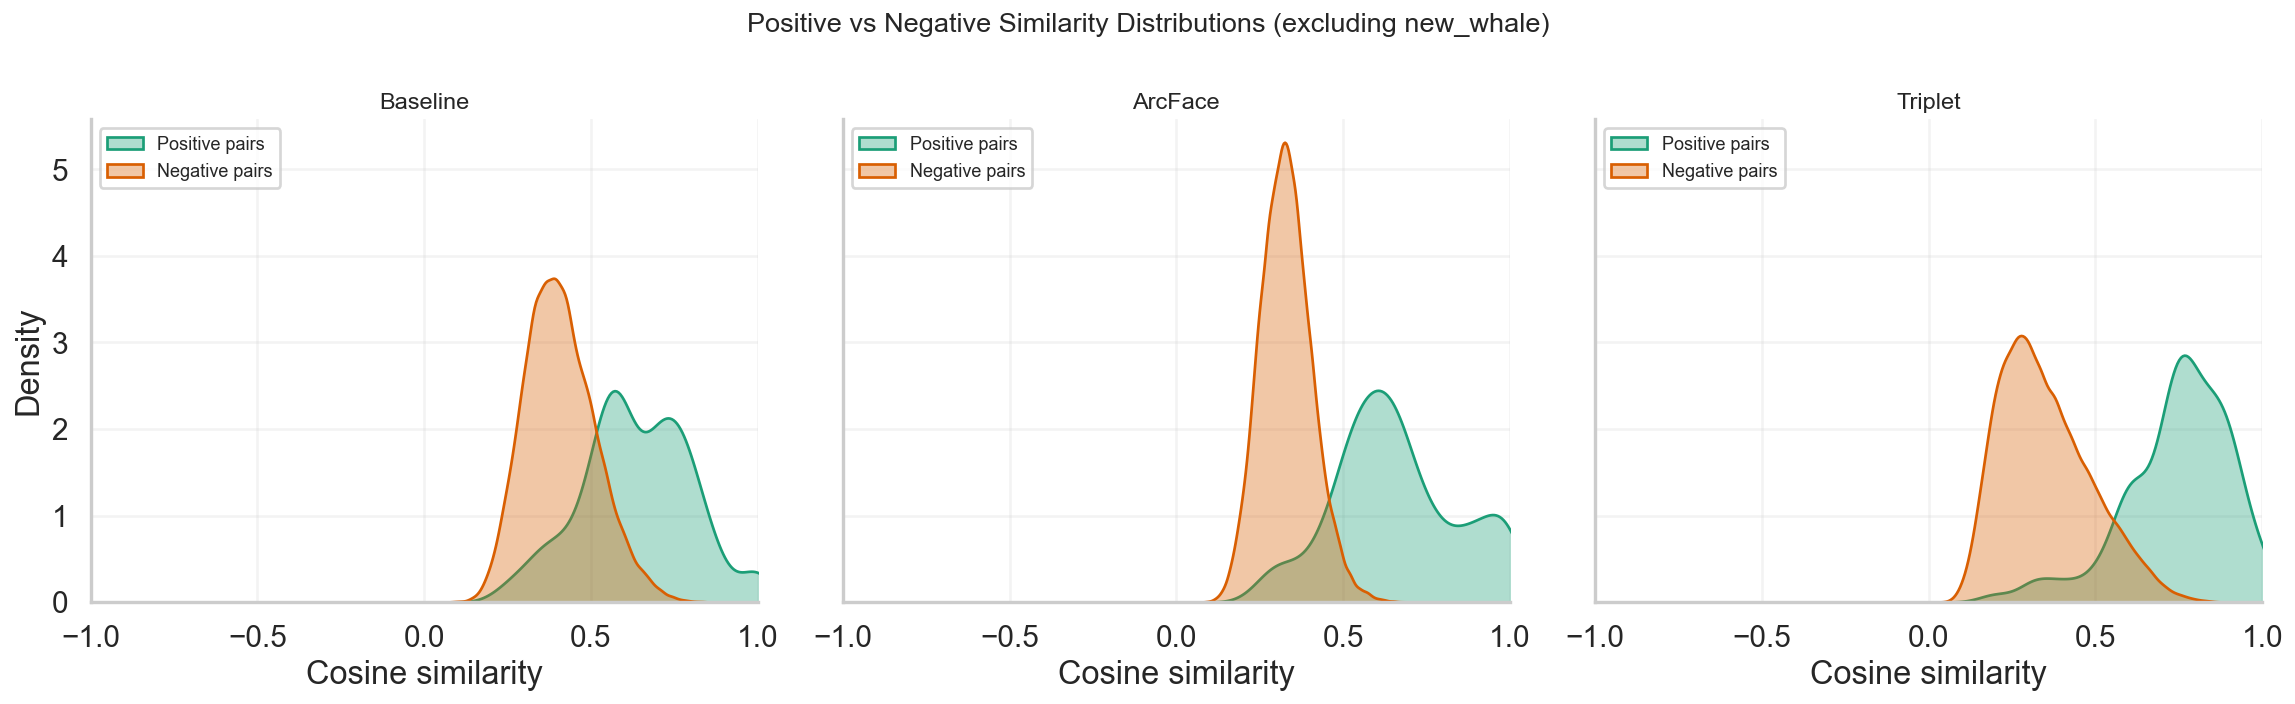

In [15]:
embeddings_by_model = {}
for model_name in ["Baseline", "ArcFace", "Triplet"]:
    model = models_dict.get(model_name)
    if model is None:
        print(f"[skip] {model_name}: model unavailable for embedding extraction.")
        continue
    emb, labels = extract_embeddings(model, query_loader, device, normalize=True)
    embeddings_by_model[model_name] = {"embeddings": emb, "labels": labels}
    print(f"{model_name}: extracted {len(labels)} validation embeddings.")


def pair_similarity_distributions(emb_t, labels_t, max_positive=60000, max_negative=60000, seed=42):
    rng = np.random.default_rng(seed)

    emb = emb_t.cpu().numpy().astype(np.float32)
    labels = labels_t.cpu().numpy().astype(np.int64)

    known = labels >= 0  # exclude new_whale for this analysis
    emb = emb[known]
    labels = labels[known]

    if len(emb) < 2:
        return np.array([]), np.array([])

    unique_classes = np.unique(labels)

    positives = []
    per_class_budget = max(20, max_positive // max(len(unique_classes), 1))

    for c in unique_classes:
        idx = np.where(labels == c)[0]
        if len(idx) < 2:
            continue

        n_pairs = min(per_class_budget, len(idx) * 4)
        a = rng.choice(idx, size=n_pairs, replace=True)
        b = rng.choice(idx, size=n_pairs, replace=True)
        valid = a != b
        if np.any(valid):
            sims = np.sum(emb[a[valid]] * emb[b[valid]], axis=1)
            positives.append(sims)

    positive_sims = np.concatenate(positives) if positives else np.array([])
    if len(positive_sims) > max_positive:
        take = rng.choice(len(positive_sims), size=max_positive, replace=False)
        positive_sims = positive_sims[take]

    negative_sims = []
    n = len(labels)
    attempts = 0
    while len(negative_sims) < max_negative and attempts < max_negative * 20:
        batch = min(4000, max_negative - len(negative_sims))
        a = rng.integers(0, n, size=batch)
        b = rng.integers(0, n, size=batch)
        valid = labels[a] != labels[b]
        if np.any(valid):
            sims = np.sum(emb[a[valid]] * emb[b[valid]], axis=1)
            negative_sims.extend(sims.tolist())
        attempts += 1

    negative_sims = np.array(negative_sims[:max_negative], dtype=np.float32)
    return positive_sims, negative_sims


fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), sharex=True, sharey=True)
for i, model_name in enumerate(["Baseline", "ArcFace", "Triplet"]):
    ax = axes[i]
    payload = embeddings_by_model.get(model_name)

    if payload is None:
        ax.set_title(f"{model_name} (missing)")
        ax.axis("off")
        continue

    pos_sims, neg_sims = pair_similarity_distributions(
        payload["embeddings"], payload["labels"], seed=42 + i
    )

    if len(pos_sims) > 0:
        sns.kdeplot(pos_sims, ax=ax, fill=True, alpha=0.35, color="#1b9e77", label="Positive pairs")
    if len(neg_sims) > 0:
        sns.kdeplot(neg_sims, ax=ax, fill=True, alpha=0.35, color="#d95f02", label="Negative pairs")

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Cosine similarity")
    ax.set_xlim(-1.0, 1.0)
    ax.grid(alpha=0.22)
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(loc="upper left", fontsize=10)

fig.suptitle("Positive vs Negative Similarity Distributions (excluding new_whale)", fontsize=15)
plt.tight_layout()
plt.show()